# Vision Transformers: Attention on the Same Digits

This is the third notebook in the series, and it recognizes the same MNIST
digits as the other two:

1. [`basic_neural_net.ipynb`](basic_neural_net.ipynb) — a dense network in pure
   NumPy, with every gradient derived by hand.
2. [`cnn_pytorch.ipynb`](cnn_pytorch.ipynb) — a convolutional network in
   PyTorch, where autograd replaced those derivations.
3. **This notebook** — a **Vision Transformer**, replacing convolution with
   **self-attention**.

The dataset, the 80/20 split, and the random seed are identical throughout, so
the three results are directly comparable.

Following the pattern of the series, the attention mechanism is written from
scratch. We do not call `nn.MultiheadAttention` or `nn.TransformerEncoderLayer`;
we build both, so that the tensor shapes and the softmax are visible. Section 12
builds the same model from PyTorch's built-ins once you have seen what it does.

## The result, stated up front

| Notebook | Architecture | Parameters | Validation accuracy |
|---|---|---|---|
| 1 | Dense, NumPy | 7,960 | 90.8% |
| 2 | CNN, PyTorch | 9,098 | 98.1% |
| 3 | **ViT (this one)** | **105,098** | **~97.5–98%** |

The Vision Transformer uses **eleven times** the parameters of the CNN to reach
the same accuracy. The two are statistically indistinguishable on 8,400
validation images — repeated runs of this notebook vary by a few tenths of a
point on their own — so read this as *parity at 11.6× the cost*, not as a
ranking. Section 13 explains why that happens, why it is what the ViT
literature reports at this data scale, and what changes when the dataset grows.
A tutorial that quietly tuned the CNN down to make the transformer look good
would teach you nothing.

> **On reproducibility.** The seed is fixed, but GPU and Apple-silicon backends
> do not guarantee deterministic accumulation, so training diverges slightly
> between runs. Two full runs here gave 97.9% and 97.6%. Expect your numbers to
> differ in the last few tenths.

## What is new here

| Concept | Section |
|---|---|
| Images as **sets of tokens** rather than grids | 3 |
| **Tokens as a data type**, and the notation $\mathbf{T} \in \mathbb{R}^{N \times d}$ | 3.3 |
| The `[CLS]` token and positional embeddings | 4 |
| Attention as a layer whose weights are **computed from the data** | 5 |
| **Scaled dot-product attention**, and why the $\sqrt{m}$ is there | 5 |
| **Multi-head** attention | 6 |
| Layer normalization, residual connections, pre-norm blocks | 7 |
| Reading a model's **attention maps** | 11 |
| The same model from `torch.nn` built-ins, proved equivalent | 12 |

## Prerequisites

Notebook 2, or comfort with PyTorch modules and training loops. The attention
mathematics is developed from scratch.

## Notation

The mathematics here follows the token notation of Chapter 26, *Transformers*,
in **Foundations of Computer Vision**. A single token is a column vector
$\mathbf{t} \in \mathbb{R}^{d \times 1}$ — its *code vector* — and a set of
$N$ tokens is the matrix $\mathbf{T} \in \mathbb{R}^{N \times d}$ whose rows
are the transposed token vectors. Section 3.3 introduces it in full and gives a
table mapping every symbol to the variable that carries it in the code.

---
## 1. Setup

Identical to the CNN notebook: same imports, same seed, same device selection.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from matplotlib import pyplot as plt

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"PyTorch {torch.__version__}")
print(f"device: {device}")

PyTorch 2.7.1
device: mps


---
## 2. The data

Unchanged from the previous two notebooks — the same `train.csv`, the same
shuffle with the same seed, the same 80/20 split. Images arrive in NCHW form,
$m \times 1 \times 28 \times 28$, exactly as the CNN consumed them. Everything
new happens in Section 3, when we cut them into patches.

In [2]:
from pathlib import Path

# Where train.csv might live, checked in order.
CANDIDATE_PATHS = [
    Path("data/train.csv.gz"),                                  # ships with this repository
    Path("data/train.csv"),                                     # uncompressed, if you have it
    Path("train.csv.gz"),                                       # same folder
    Path("train.csv"),                                          # same folder
    Path("/content/drive/MyDrive/digit-recognizer/train.csv"),  # Drive, inside Colab
]

# Google Drive for Desktop syncs Drive into a local folder whose exact name
# depends on the account, so we glob for it rather than hard-coding one.
DRIVE_PATTERNS = [
    "My Drive*/digit-recognizer/train.csv",
    "Google Drive*/digit-recognizer/train.csv",
    "Library/CloudStorage/GoogleDrive*/My Drive/digit-recognizer/train.csv",
]


def locate_training_csv():
    """Find train.csv locally, in a synced Google Drive, or by mounting Drive in Colab."""
    for path in CANDIDATE_PATHS:
        if path.exists():
            return path

    # Google Drive for Desktop, already synced onto this machine.
    for pattern in DRIVE_PATTERNS:
        for path in sorted(Path.home().glob(pattern)):
            return path

    # Running inside Colab: mount Drive, then look again.
    try:
        from google.colab import drive
    except ImportError:
        pass
    else:
        drive.mount("/content/drive")
        for path in CANDIDATE_PATHS:
            if path.exists():
                return path

    raise FileNotFoundError(
        "Could not find the training data. It ships with this repository at "
        "data/train.csv.gz, so if it is missing, re-clone from "
        "https://github.com/RibeiroResearch/neural-nets-tutorials or place a "
        "copy at one of: " + ", ".join(str(p) for p in CANDIDATE_PATHS)
    )


data = np.array(pd.read_csv(locate_training_csv()))

rng = np.random.default_rng(SEED)
rng.shuffle(data)
n_train = int(0.8 * data.shape[0])


def to_tensors(rows):
    """Split a (n, 785) array into an NCHW image tensor and a label tensor."""
    images = rows[:, 1:].reshape(-1, 1, 28, 28) / 255.0
    labels = rows[:, 0]
    return (torch.tensor(images, dtype=torch.float32),
            torch.tensor(labels, dtype=torch.long))


X_train, Y_train = to_tensors(data[:n_train])
X_val, Y_val = to_tensors(data[n_train:])

BATCH_SIZE = 128
train_loader = DataLoader(TensorDataset(X_train, Y_train),
                          batch_size=BATCH_SIZE, shuffle=True)

print(f"X_train: {tuple(X_train.shape)}   X_val: {tuple(X_val.shape)}")
print(f"batches per epoch: {len(train_loader)}")

X_train: (33600, 1, 28, 28)   X_val: (8400, 1, 28, 28)
batches per epoch: 263


---
## 3. An image as a set of tokens

A transformer does not consume pixels, and it has no notion of a grid. It
consumes **tokens**, so before anything else we have to decide what a token is
for an image.

Chapter 26 poses the question by analogy. How did we *neuronize* an image for
the dense network of Notebook 1? We gave each pixel a neuron. To **tokenize** an
image, we give each patch of pixels a token. That one sentence is the design
decision; the rest of this section works out what it costs and what it throws
away.

### 3.1 Why not one token per pixel?

Cost. Attention compares every token with every other token, so it grows as
$O(N^2)$ in the number of tokens $N$. For $28 \times 28$ images:

$$
N = 784 \quad\Longrightarrow\quad N^2 = 614{,}656 \text{ pairs per head, per layer.}
$$

For a $224 \times 224$ photograph it would be $50{,}176^2 \approx 2.5$ billion.
This quadratic cost is the most important practical fact about attention, and it
is what makes patching necessary rather than merely convenient.

### 3.2 Tokenizing the image

Cut the image into a grid of non-overlapping $P \times P$ patches and make each
patch one token. With $P = 7$ on a $28 \times 28$ image:

$$
N = \left(\frac{28}{7}\right)^2 = 4 \times 4 = 16 \text{ patches,}
\qquad
\text{each flattened to } \mathbb{R}^{7 \cdot 7} = \mathbb{R}^{49}.
$$

Now $N^2 = 256$ pairs. Each vectorized patch is projected to the model width $d$
by a single shared linear map, which the chapter names
$\mathbf{W}_{\texttt{tokenize}}$:

$$
\mathbf{t}_i \;=\; \mathbf{W}_{\texttt{tokenize}}\; \mathrm{vec}(\text{patch}_i) \;+\; \mathbf{b},
\qquad \mathbf{W}_{\texttt{tokenize}} \in \mathbb{R}^{d \times 49}.
$$

Each $\mathbf{t}_i \in \mathbb{R}^{d \times 1}$ is a token's **code vector** —
the whole content of token $i$, and the only thing any later layer will ever see
of patch $i$.

Two observations are worth making now, because they explain the accuracy result
at the end.

**Tokenizing discards the grid.** After this step the model holds an unordered
*set* of 16 vectors. That patch 5 sat directly above patch 9 in the image is
information the architecture no longer has; Section 4 has to put a weakened
version of it back by hand.

**The tokenizer is a convolution.** Applying the same
$\mathbf{W}_{\texttt{tokenize}}$ to every non-overlapping $7 \times 7$ patch is
a `Conv2d` with kernel 7 and stride 7. So a ViT does begin with one
convolutional layer — it simply has no others, and its kernel is as large as its
stride, so nothing local survives past the first step.


In [3]:
PATCH = 7
N_PATCHES = (28 // PATCH) ** 2
PATCH_DIM = PATCH * PATCH


def patchify(images, patch=PATCH):
    """(B, 1, 28, 28) -> (B, 16, 49), row-major over the patch grid."""
    B = images.shape[0]
    patches = images.unfold(2, patch, patch).unfold(3, patch, patch)
    # patches: (B, 1, 4, 4, 7, 7) -> flatten grid and pixels
    return patches.reshape(B, N_PATCHES, PATCH_DIM)


tokens = patchify(X_train[:4])
print(f"{tuple(X_train[:4].shape)} -> {tuple(tokens.shape)}")
print(f"sequence length N = {N_PATCHES}, patch dimension = {PATCH_DIM}")
print(f"attention pairs per head: N^2 = {N_PATCHES ** 2}")
print(f"one token per pixel would give: {784 ** 2:,}")

(4, 1, 28, 28) -> (4, 16, 49)
sequence length N = 16, patch dimension = 49
attention pairs per head: N^2 = 256
one token per pixel would give: 614,656


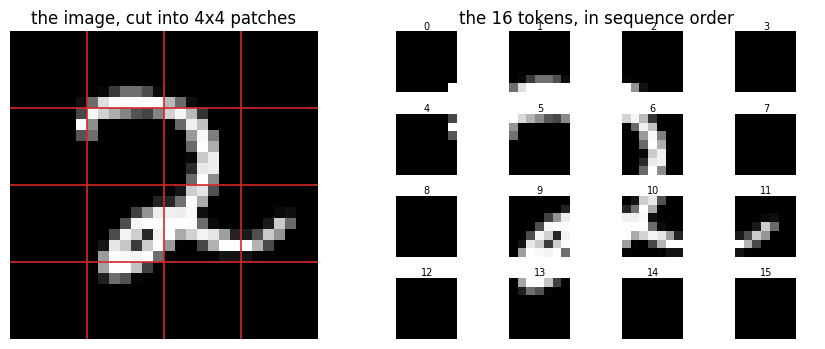

In [4]:
# Show the patch grid for one digit.
example = X_train[0, 0]
grid = int(28 // PATCH)

fig = plt.figure(figsize=(9, 3.6))
ax_full = fig.add_subplot(1, 2, 1)
ax_full.imshow(example, cmap="gray")
for k in range(1, grid):
    ax_full.axhline(k * PATCH - 0.5, color="tab:red", lw=1.2)
    ax_full.axvline(k * PATCH - 0.5, color="tab:red", lw=1.2)
ax_full.set_title(f"the image, cut into {grid}x{grid} patches")
ax_full.axis("off")

# The same patches laid out as the sequence the transformer receives.
sub = fig.add_subplot(1, 2, 2)
sub.set_title(f"the {N_PATCHES} tokens, in sequence order")
sub.axis("off")
inner = sub.get_subplotspec().subgridspec(grid, grid, hspace=0.35, wspace=0.15)
patch_tokens = patchify(X_train[0:1])[0]
for i in range(N_PATCHES):
    ax = fig.add_subplot(inner[i // grid, i % grid])
    ax.imshow(patch_tokens[i].reshape(PATCH, PATCH), cmap="gray")
    ax.set_title(str(i), fontsize=7, pad=2)
    ax.axis("off")

plt.tight_layout()
plt.show()

### 3.3 Notation: tokens as a data type

Chapter 26 treats a token as a new **data type**, and the notation follows from
that. A single token is a column vector, its code vector:

$$
\mathbf{t} \in \mathbb{R}^{d \times 1}.
$$

A set of $N$ tokens is stacked into a matrix, each token **transposed into a
row**:

$$
\mathbf{T} \;=\;
\begin{bmatrix}
\mathbf{t}_1^{\mathsf{T}} \\
\vdots \\
\mathbf{t}_N^{\mathsf{T}}
\end{bmatrix}
\;\in\; \mathbb{R}^{N \times d},
\qquad
\mathbf{T}[i,:] \;=\; \mathbf{t}_i^{\mathsf{T}} .
$$

We index rows from $1$ to $N$ throughout the mathematics; the code, and the
chapter's own $\mathbf{T}[0,:]$ form, count from $0$.

The row convention is worth pausing on, because it is not arbitrary. It is the
layout the tensors already have in memory — ours are `(B, N, d)`, with tokens
along the second axis — and it is the layout `nn.Linear` expects, since
`nn.Linear` holds a weight of shape `(out, in)` and computes
$\mathbf{x}\mathbf{W}^{\mathsf{T}}$ on rows. Writing the mathematics in rows
means the equations below transcribe into code without a transpose appearing
from nowhere.

#### The analogy that motivates it

> *Tokens are to transformers as neurons are to neural nets.*

An MLP takes a column vector $\mathbf{x}$ whose entries are **scalar** neurons.
A transformer takes an array $\mathbf{T}$ whose entries are **vector-valued**
tokens. One equation covers both; only the type of the element changes:

$$
\begin{aligned}
\mathbf{x}_{\texttt{out}} &= \mathbf{W}\mathbf{x}_{\texttt{in}}
&&\triangleleft\;\; \text{linear combination of neurons} \\[4pt]
\mathbf{T}_{\texttt{out}} &= \mathbf{W}\mathbf{T}_{\texttt{in}}
&&\triangleleft\;\; \text{linear combination of tokens}
\end{aligned}
$$

Read row $i$ of the second line and the difference is plain:

$$
\mathbf{T}_{\texttt{out}}[i,:] \;=\; \sum_{j=1}^{N} w_{ij}\, \mathbf{T}_{\texttt{in}}[j,:]
$$

— a weighted sum of whole tokens, where the neuron version sums scalars.

#### Two operations, and where they live in this notebook

A transformer is built from two things, and they are the token-level analogues
of the two workhorses of an ordinary network:

| Neural net | Token net | This notebook |
|---|---|---|
| linear layer — **mixes** neurons | **mixing tokens** by weighted sum | attention, Sections 5–6 |
| pointwise nonlinearity — one neuron at a time | **modifying tokens**, one token at a time | LayerNorm and the MLP, Section 7 |

Keep that table in view for the rest of the notebook. Every line of
`TransformerBlock` in Section 7 is one or the other, and Section 5 is entirely
about what makes the mixing in row one interesting: its weights are not free
parameters, they are computed from the data.

#### Symbols, and the variables that carry them

| Symbol | Meaning | In the code |
|---|---|---|
| $N$ | number of tokens | `N_PATCHES + 1` — the `N` axis |
| $d$ | token code-vector width | `D_MODEL`, `d_model` |
| $\mathbf{t}_i$ | one token's code vector | a single row of `z` |
| $\mathbf{T}$ | the token array, $N \times d$ | `z`, batched as `(B, N, d)` |
| $\mathbf{W}_{\texttt{tokenize}}$ | patch $\to$ token projection | `patch_embed` |
| $\mathbf{W}_q, \mathbf{W}_k, \mathbf{W}_v$ | query/key/value projections | `qkv`, the three fused |
| $m$ | query/key width, per head | `self.d_k` |
| $\mathbf{A}$ | attention matrix, $N \times N$ | `weights` |
| $h$ | number of heads | `N_HEADS` |
| $\mathbf{W}_{\texttt{MSA}}$ | head-merge projection | `proj` |

The code keeps the PyTorch-conventional names rather than the chapter's symbols,
which is the usual state of affairs when you read a paper next to an
implementation. This table is the bridge.

Two deliberate departures from the chapter, both flagged again where they arise:
it writes $k$ for the number of heads, which collides with the key vectors
$\mathbf{k}_j$ in the same equations, so we write $h$; and it writes $m$ for the
query/key width, where most papers — and PyTorch — write $d_k$.


---
## 4. The `[CLS]` token and positional embeddings

### 4.1 Attention does not know about order

Here is the property that forces everything in this section. Self-attention is
**permutation equivariant**: permute the input tokens and the output tokens are
permuted the same way, with no other change. For a permutation matrix
$\mathbf{\Pi}$,

$$
\operatorname{Attention}(\mathbf{\Pi}\mathbf{T}) \;=\; \mathbf{\Pi} \operatorname{Attention}(\mathbf{T}).
$$

The reason is visible in the formula we will derive in Section 5: attention
forms all pairwise scores $\mathbf{q}_i^{\mathsf{T}}\mathbf{k}_j$ and takes
weighted sums. Nothing in that computation refers to $i$ or $j$ as *positions* —
only as identities. This is why the chapter insists that a group of tokens is a
**set**, not a sequence: shuffle the 16 patches of a digit and a transformer,
unaided, computes exactly the same answer.

That is fatal for images, where a stroke in the top-left means something
different from the same stroke in the bottom-right. Note the contrast with
convolution, which is translation *equivariant* — it knows where things are and
that shifting them shifts the output — whereas attention is permutation
equivariant, a far weaker structural assumption.

### 4.2 Positional embeddings

The fix is to give each token a position-dependent vector before the first
block:

$$
\mathbf{T}^{(0)}[i,:] \;=\; \mathbf{t}_i^{\mathsf{T}} + \mathbf{p}_i^{\mathsf{T}},
\qquad i = 1, \dots, N .
$$

We use **learned** positional embeddings, as the original ViT does:
$\mathbf{p}_i$ is a parameter, trained with everything else.

Two differences from the chapter are worth noting, because both are choices
rather than necessities. Section 26.11 *concatenates* a positional code onto
each token, and builds that code from sinusoids of the $x$ and $y$ coordinates;
ViT *adds* a learned vector of width $d$ instead. Adding keeps the token width
at $d$ rather than growing it, and learning lets the model decide for itself how
much of its budget position deserves.

The embeddings are indexed by patch, so $\mathbf{p}_i$ is tied to a particular
position in the $4 \times 4$ patch grid. That has a consequence worth knowing
before you fine-tune a pretrained ViT: **the positional embeddings are tied to
the input resolution they were trained at.** A backbone pretrained on
$224 \times 224$ images with $16 \times 16$ patches holds embeddings for a
$14 \times 14$ grid. Feed it a different resolution and the grid no longer
matches, so the embeddings have to be interpolated onto the new grid — usually
bicubic over the two spatial dimensions. Resizing inputs to the backbone's
native resolution avoids the problem entirely, which is why most fine-tuning
recipes do exactly that.

It is worth being clear that this is a **weaker** mechanism than a convolution's
built-in locality. Nothing tells the model that position 5 is adjacent to
position 9; it must discover that from data. Section 13 returns to the cost of
this.

### 4.3 The `[CLS]` token

The chapter ends a transformer with an output layer that makes a prediction "as
a function of the final set of tokens", and leaves that function open. Two
choices are standard: average the final tokens, or prepend one extra learned
**classification token** and read only its output. We take the second,
following ViT and BERT, which prepends a token to the set:

$$
\mathbf{T}^{(0)} \;=\;
\begin{bmatrix}
\mathbf{t}_{\texttt{cls}}^{\mathsf{T}} \\
(\mathbf{t}_1 + \mathbf{p}_1)^{\mathsf{T}} \\
\vdots \\
(\mathbf{t}_N + \mathbf{p}_N)^{\mathsf{T}}
\end{bmatrix}
\;\in\; \mathbb{R}^{(N+1) \times d}
$$

The `[CLS]` token carries no information about the image — it is the same
learned vector for every input. What makes it useful is that attention lets it
*gather* information: at every layer it attends over all the patch tokens, so by
the final layer its code vector is a learned, input-dependent summary of the
image. We classify from that one vector, and in Section 11 we visualize
which patches it chose to read.

Our token count is therefore $N + 1 = 17$.


In [5]:
D_MODEL = 64
N_HEADS = 4
N_LAYERS = 2
MLP_RATIO = 4

# The three learned pieces introduced in this section.
patch_embed = nn.Linear(PATCH_DIM, D_MODEL)
cls_token = nn.Parameter(torch.zeros(1, 1, D_MODEL))
pos_embed = nn.Parameter(torch.zeros(1, N_PATCHES + 1, D_MODEL))

with torch.no_grad():
    embedded = patch_embed(patchify(X_train[:2]))              # (2, 16, 64)
    with_cls = torch.cat([cls_token.expand(2, -1, -1), embedded], dim=1)
    z0 = with_cls + pos_embed                                  # (2, 17, 64)

print(f"patches embedded:      {tuple(embedded.shape)}")
print(f"after prepending CLS:  {tuple(with_cls.shape)}")
print(f"after adding position: {tuple(z0.shape)}   <- input to block 1")

patches embedded:      (2, 16, 64)
after prepending CLS:  (2, 17, 64)
after adding position: (2, 17, 64)   <- input to block 1


---
## 5. Scaled dot-product attention

### 5.1 Attention is a mixing layer with data-dependent weights

Section 3.3 gave the general form of mixing tokens,
$\mathbf{T}_{\texttt{out}} = \mathbf{W}\mathbf{T}_{\texttt{in}}$, where
$\mathbf{W}$ is a matrix of free parameters — fixed once training ends, the same
for every image. An **attention layer** is that same equation with one change,
and the whole chapter turns on it:

$$
\begin{aligned}
\mathbf{A} &= f(\mathbf{T}_{\texttt{in}}) &&\triangleleft\;\; \text{computed from the data} \\[4pt]
\mathbf{T}_{\texttt{out}} &= \mathbf{A}\mathbf{T}_{\texttt{in}}
\end{aligned}
$$

The **attention matrix** $\mathbf{A}$ occupies the slot $\mathbf{W}$ had, but its
entries are a function of the input rather than parameters, and they are
non-negative, so each row reads as an allocation of attention across the input
tokens. A linear layer applies the same mixing to every image; an attention
layer picks a different mixing for each one.

Everything that follows is the answer to a single question: what is $f$?

### 5.2 Queries, keys, and values

Transformers answer it with **query-key-value attention**. Each token's code
vector is projected into three roles by three learned matrices:

$$
\mathbf{q} = \mathbf{W}_q \mathbf{t}, \qquad
\mathbf{k} = \mathbf{W}_k \mathbf{t}, \qquad
\mathbf{v} = \mathbf{W}_v \mathbf{t}
$$

The names come from an analogy with database lookup, and it is a good one: a
cell holds a **value**, retrieved when a **query** matches the cell's **key**.

* the query $\mathbf{q}_i$ describes what token $i$ is looking for;
* the key $\mathbf{k}_j$ describes what token $j$ offers;
* the value $\mathbf{v}_j$ is what token $j$ contributes if attended to.

A hard database returns the one value whose key matches. Attention is the soft
version: it compares the query against *every* key and returns a weighted
average of all values.

Applying the same three projections to every token gives three matrices. Because
our tokens are rows, each projection appears transposed — which is exactly what
`nn.Linear` computes:

$$
\mathbf{Q} = \mathbf{T}\mathbf{W}_q^{\mathsf{T}}, \qquad
\mathbf{K} = \mathbf{T}\mathbf{W}_k^{\mathsf{T}}, \qquad
\mathbf{V} = \mathbf{T}\mathbf{W}_v^{\mathsf{T}}
$$

with $\mathbf{Q}, \mathbf{K} \in \mathbb{R}^{N \times m}$ and
$\mathbf{V} \in \mathbb{R}^{N \times m}$. Queries and keys must share the width
$m$ because we take their dot product. (Most papers, and PyTorch, write $d_k$
for this width; the code below calls it `d_k`.)

The value width is free in principle, and the choice made here is worth
flagging. A lone attention layer usually gives values width $d$, so that its
output is a set of code vectors again. Ours are width $m$ instead, because
Section 6 runs $h$ of these layers side by side and restores the width $d$ once,
at the end, with a single merge matrix.

### 5.3 The formula

Similarity is the dot product, scaled and turned into weights by a row-wise
softmax:

$$
\boxed{\;
\mathbf{A} \;=\; \operatorname{softmax}\!\left(\frac{\mathbf{Q} \mathbf{K}^{\mathsf{T}}}{\sqrt{m}}\right),
\qquad
\mathbf{T}_{\texttt{out}} \;=\; \mathbf{A}\mathbf{V}
\;}
$$

Note what sits on the right of the second equation: the weighted sum is taken
over the **value** vectors, not over the token code vectors directly. That is
the one place the attention layer departs from the plain mixing equation of
Section 3.3.

Reading it one token at a time makes the shapes concrete. For query $i$:

$$
\mathbf{A}[i,j] = \frac{\exp\!\left(\mathbf{q}_i^{\mathsf{T}} \mathbf{k}_j / \sqrt{m}\right)}
                   {\sum_{j'} \exp\!\left(\mathbf{q}_i^{\mathsf{T}} \mathbf{k}_{j'} / \sqrt{m}\right)},
\qquad
\mathbf{T}_{\texttt{out}}[i,:] = \sum_{j=1}^{N} \mathbf{A}[i,j]\, \mathbf{v}_j^{\mathsf{T}}
$$

The entries of $\mathbf{A}$ are non-negative and each row sums to one: row $i$ is
a probability distribution describing how token $i$ divides its attention across
the set. That matrix is $N \times N$ — this is the quadratic cost of Section 3 —
and it is what we will plot in Section 11.

| Quantity | Shape |
|---|---|
| $\mathbf{T}$ | $N \times d$ |
| $\mathbf{Q}, \mathbf{K}, \mathbf{V}$ | $N \times m$ |
| $\mathbf{Q}\mathbf{K}^{\mathsf{T}}$ (scores) | $N \times N$ |
| $\mathbf{A}$ (weights) | $N \times N$, rows sum to 1 |
| $\mathbf{T}_{\texttt{out}}$ | $N \times m$ |

### 5.4 Why divide by $\sqrt{m}$?

This is the detail often quoted without justification.

Suppose the entries of $\mathbf{q}$ and $\mathbf{k}$ are independent with mean
$0$ and variance $1$. Their dot product is
$\mathbf{q}^{\mathsf{T}}\mathbf{k} = \sum_{c=1}^{m} q_c k_c$, a sum of $m$
independent terms each with mean $0$ and variance $1$. Therefore

$$
\mathbb{E}[\mathbf{q}^{\mathsf{T}}\mathbf{k}] = 0,
\qquad
\operatorname{Var}(\mathbf{q}^{\mathsf{T}}\mathbf{k}) = m .
$$

The scores grow like $\sqrt{m}$ in magnitude. Feed large scores into a softmax
and it saturates: one weight approaches $1$, the rest approach $0$. And a
saturated softmax has a vanishing gradient — if $\alpha \approx 1$ or
$\approx 0$, then $\alpha(1 - \alpha) \approx 0$ and learning stalls.

Dividing by $\sqrt{m}$ restores unit variance:

$$
\operatorname{Var}\!\left(\frac{\mathbf{q}^{\mathsf{T}}\mathbf{k}}{\sqrt{m}}\right)
= \frac{m}{m} = 1 .
$$

The cell below measures this rather than asserting it.


In [6]:
# The variance argument of Section 5.3, verified numerically.
torch.manual_seed(0)
for d_k in [16, 64, 256]:
    q = torch.randn(4096, d_k)
    k = torch.randn(4096, d_k)
    raw = (q * k).sum(dim=1)
    print(f"d_k = {d_k:4d}:  Var(q.k) = {raw.var():7.2f}  (= d_k)   "
          f"Var(q.k / sqrt(d_k)) = {(raw / d_k ** 0.5).var():.3f}")

d_k =   16:  Var(q.k) =   15.73  (= d_k)   Var(q.k / sqrt(d_k)) = 0.983
d_k =   64:  Var(q.k) =   64.19  (= d_k)   Var(q.k / sqrt(d_k)) = 1.003
d_k =  256:  Var(q.k) =  251.20  (= d_k)   Var(q.k / sqrt(d_k)) = 0.981


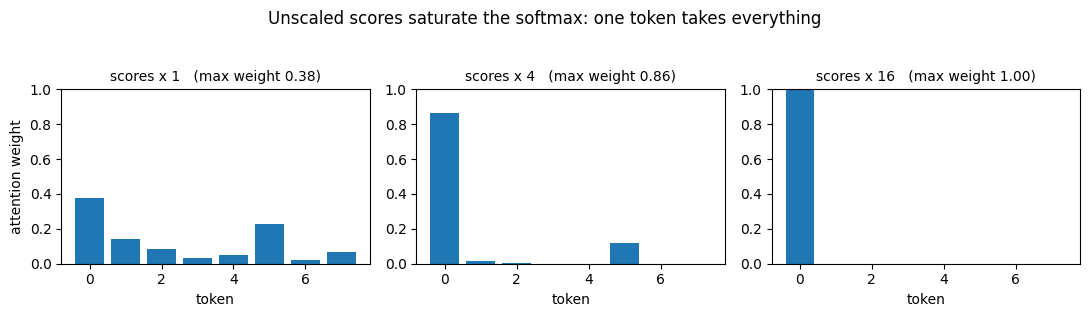

In [7]:
# What saturation does to the softmax.
scores = torch.tensor([2.0, 1.0, 0.5, -0.5, 0.0, 1.5, -1.0, 0.25])

fig, axes = plt.subplots(1, 3, figsize=(11, 3.0))
for ax, scale in zip(axes, [1.0, 4.0, 16.0]):
    weights = torch.softmax(scores * scale, dim=0)
    ax.bar(range(len(scores)), weights)
    ax.set_ylim(0, 1)
    ax.set_title(f"scores x {scale:g}   (max weight {weights.max():.2f})", fontsize=10)
    ax.set_xlabel("token")
axes[0].set_ylabel("attention weight")
fig.suptitle("Unscaled scores saturate the softmax: one token takes everything", y=1.04)
plt.tight_layout()
plt.show()

The left panel is a usable distribution; the right panel has collapsed onto a
single token and will pass almost no gradient. Dividing by $\sqrt{m}$ is what
keeps a freshly initialized model in the left-hand regime.

---
## 6. Multi-head attention

One attention layer produces one $\mathbf{A}$ — a single opinion about what is
relevant. The limitation is easier to see by expanding a single score:

$$
s_{ij} \;=\; \mathbf{q}_i^{\mathsf{T}}\mathbf{k}_j
\;=\; (\mathbf{W}_q \mathbf{t}_i)^{\mathsf{T}} \mathbf{W}_k \mathbf{t}_j
\;=\; \mathbf{t}_i^{\mathsf{T}} \underbrace{\mathbf{W}_q^{\mathsf{T}} \mathbf{W}_k}_{\mathbf{S}} \mathbf{t}_j
$$

The pair $\mathbf{W}_q, \mathbf{W}_k$ does nothing but define a single matrix
$\mathbf{S}$ that fixes *one* notion of similarity between token code vectors.
But a token may need several unrelated things at once: in an image, the patch
below and the patch two to the left, matched for different reasons.

**Multi-head attention** runs $h$ attention layers in parallel on the same
input, concatenates their outputs, and projects back to width $d$:

$$
\begin{aligned}
\mathbf{T}_{\texttt{out}}^{\,l} &= \operatorname{attn}^{l}(\mathbf{T}_{\texttt{in}}),
\qquad l = 1, \dots, h \\[4pt]
\bar{\mathbf{T}}_{\texttt{out}} &= \left[\, \mathbf{T}_{\texttt{out}}^{\,1} \;\big|\; \cdots \;\big|\; \mathbf{T}_{\texttt{out}}^{\,h} \,\right]
&&\triangleleft\;\; \bar{\mathbf{T}}_{\texttt{out}} \in \mathbb{R}^{N \times hm} \\[4pt]
\mathbf{T}_{\texttt{out}} &= \bar{\mathbf{T}}_{\texttt{out}}\, \mathbf{W}_{\texttt{MSA}}
&&\triangleleft\;\; \mathbf{W}_{\texttt{MSA}} \in \mathbb{R}^{hm \times d}
\end{aligned}
$$

Each head gets its own $\mathbf{W}_q, \mathbf{W}_k, \mathbf{W}_v$, so each
defines its own $\mathbf{S}$ and measures similarity its own way. The merge
matrix $\mathbf{W}_{\texttt{MSA}}$ is learned along with them.

> The chapter writes $k$ for the number of heads. That would collide with the
> key vectors $\mathbf{k}_j$ in the equations above, so this notebook writes $h$.

Setting $m = d / h$ makes $hm = d$, so the concatenation returns to width $d$
and multi-head attention costs **no more** than single-head attention at the
same width — it partitions the existing budget into $h$ independent subspaces
rather than enlarging it. With $d = 64$ and $h = 4$, each head works in 16
dimensions.

### Implementation

The three projections are computed as one $d \to 3d$ matrix and split, which is
faster than three separate matrix products. The head dimension is then unfolded
and moved next to the batch axis, so a single batched matrix multiply handles
every head at once:

$$
(B,\, N,\, d)
\;\to\; (B,\, N,\, h,\, m)
\;\to\; (B,\, h,\, N,\, m)
$$

After that, `q @ k.transpose(-2, -1)` produces the $(B, h, N, N)$ stack of
attention matrices directly — one $\mathbf{A}$ per head, per image.


In [8]:
class MultiHeadSelfAttention(nn.Module):
    """Scaled dot-product attention with h heads, written out explicitly."""

    def __init__(self, d_model=D_MODEL, n_heads=N_HEADS):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must divide evenly into heads"
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)   # W^Q, W^K, W^V fused
        self.proj = nn.Linear(d_model, d_model)      # W^O

    def forward(self, z, return_attention=False):
        B, N, D = z.shape

        # Project once, then split into the three roles.
        q, k, v = self.qkv(z).chunk(3, dim=-1)       # each (B, N, D)

        # (B, N, D) -> (B, h, N, d_k)
        def split_heads(t):
            return t.view(B, N, self.n_heads, self.d_k).transpose(1, 2)

        q, k, v = split_heads(q), split_heads(k), split_heads(v)

        scores = q @ k.transpose(-2, -1) / self.d_k ** 0.5   # (B, h, N, N)
        weights = scores.softmax(dim=-1)                     # rows sum to 1
        context = weights @ v                                # (B, h, N, d_k)

        # (B, h, N, d_k) -> (B, N, D), then mix the heads with W^O.
        context = context.transpose(1, 2).reshape(B, N, D)
        output = self.proj(context)

        return (output, weights) if return_attention else output

In [9]:
# Shapes, and the defining property: every attention row is a distribution.
attention = MultiHeadSelfAttention()
out, weights = attention(z0, return_attention=True)

print(f"input       {tuple(z0.shape)}")
print(f"output      {tuple(out.shape)}")
print(f"weights     {tuple(weights.shape)}  = (batch, heads, N, N)")
print(f"row sums    min {weights.sum(-1).min():.6f}  max {weights.sum(-1).max():.6f}")
print(f"all non-negative: {(weights >= 0).all().item()}")

input       (2, 17, 64)
output      (2, 17, 64)
weights     (2, 4, 17, 17)  = (batch, heads, N, N)
row sums    min 1.000000  max 1.000000
all non-negative: True


In [10]:
# Permutation equivariance (Section 4.1), demonstrated on the patch tokens.
torch.manual_seed(0)
probe = MultiHeadSelfAttention()
tokens_only = z0[:1, 1:, :]                      # drop CLS, keep 16 patches
perm = torch.randperm(tokens_only.shape[1])

with torch.no_grad():
    out_then_permute = probe(tokens_only)[:, perm, :]
    permute_then_out = probe(tokens_only[:, perm, :])

print("Attention(PX) == P Attention(X)?",
      torch.allclose(out_then_permute, permute_then_out, atol=1e-6))
print("\nThis is why positional embeddings are not optional:")
print("without them, a shuffled digit is literally the same input.")

Attention(PX) == P Attention(X)? True

This is why positional embeddings are not optional:
without them, a shuffled digit is literally the same input.


---
## 7. The transformer block

Attention alone is not a network. It is one of the two operations from Section
3.3 — mixing tokens — and mixing on its own is linear, exactly as stacked linear
layers are linear in an ordinary net. This section supplies the other operation,
**modifying each token individually**, and two pieces of engineering that make a
deep stack of the pair trainable.

### 7.1 Residual connections

Every sublayer is added to its input rather than replacing it:

$$
\mathbf{T} \;\leftarrow\; \mathbf{T} + \operatorname{Sublayer}(\mathbf{T})
$$

The gradient consequence is the point. Differentiating,
$\partial \mathbf{T}_{\texttt{out}} / \partial \mathbf{T}_{\texttt{in}} = \mathbf{I} + \partial \operatorname{Sublayer} / \partial \mathbf{T}_{\texttt{in}}$,
so there is always an identity path along which gradients flow undiminished, no
matter how deep the stack. Without it, deep transformers do not train.

### 7.2 Layer normalization, or *token norm*

**LayerNorm** normalizes each token across its own code vector. Writing $t_c$
for component $c$ of the token $\mathbf{t}$:

$$
\operatorname{LN}(\mathbf{t}) = \boldsymbol{\gamma} \odot \frac{\mathbf{t} - \mu}{\sqrt{\sigma^2 + \epsilon}} + \boldsymbol{\beta},
\qquad
\mu = \frac{1}{d}\sum_{c=1}^{d} t_c,
\quad
\sigma^2 = \frac{1}{d}\sum_{c=1}^{d} (t_c - \mu)^2
$$

with learned $\boldsymbol{\gamma}, \boldsymbol{\beta} \in \mathbb{R}^{d}$.

Chapter 26 calls this **token norm**, which is the more descriptive name: the
statistics come from inside one token and nowhere else, so it is a *tokenwise*
operation, of the same kind as the MLP below. Its description of token norm
omits $\boldsymbol{\gamma}$ and $\boldsymbol{\beta}$; `nn.LayerNorm` includes
them by default and ViT uses them, so ours are learned.

The contrast with **BatchNorm** — the natural choice in a CNN — is the reason
transformers use this one. BatchNorm normalizes each feature across the batch,
so a token's representation depends on which other examples happen to share its
batch, and it needs separate train and inference behaviour with running
statistics. LayerNorm's statistics come from a single token's own code vector:
independent of batch size, identical at training and inference, and indifferent
to how many tokens there are. For variable-length token sets that last property
is decisive.

### 7.3 The tokenwise MLP

Here is the second of the chapter's two operations. Attention *mixes*
information between tokens but applies no per-token nonlinearity beyond the
softmax. The MLP supplies it, acting on each token separately with shared
weights:

$$
F(\mathbf{t}) = \mathbf{W}_2 \,\operatorname{GELU}(\mathbf{W}_1 \mathbf{t} + \mathbf{b}_1) + \mathbf{b}_2,
\qquad \mathbf{W}_1 \in \mathbb{R}^{4d \times d},\;\; \mathbf{W}_2 \in \mathbb{R}^{d \times 4d}
$$

applied row by row across the whole set:

$$
\operatorname{MLP}(\mathbf{T}) =
\begin{bmatrix}
F(\mathbf{T}[1,:]) \\
\vdots \\
F(\mathbf{T}[N,:])
\end{bmatrix}
$$

This is the exact analogue of a pointwise nonlinearity in an ordinary network,
promoted from scalars to vectors: no token can see any other token inside it.
Note that it is *not* pointwise in the neurons — $\mathbf{W}_1$ mixes the $d$
components within a token freely. What it cannot do is mix across tokens. That
job belongs to attention alone, and keeping the two separable is what makes the
architecture easy to reason about.

The $4\times$ expansion is conventional and is where most transformer parameters
live. **GELU**, $\operatorname{GELU}(x) = x \cdot \Phi(x)$ with $\Phi$ the
standard normal CDF, is a smooth relative of ReLU that is standard in
transformers.

### 7.4 Pre-norm

The order of operations matters. The original paper used *post-norm*,
$\mathbf{T} \leftarrow \operatorname{LN}(\mathbf{T} + \operatorname{Sublayer}(\mathbf{T}))$,
which needs a learning-rate warmup to train stably. Current practice is
**pre-norm**:

$$
\begin{aligned}
\mathbf{T} &\;\leftarrow\; \mathbf{T} + \operatorname{MultiHead}\!\left(\operatorname{LN}(\mathbf{T})\right)
&&\triangleleft\;\; \text{mix tokens} \\
\mathbf{T} &\;\leftarrow\; \mathbf{T} + \operatorname{MLP}\!\left(\operatorname{LN}(\mathbf{T})\right)
&&\triangleleft\;\; \text{modify each token}
\end{aligned}
$$

Here the residual path is clean — no normalization sits on it — so gradients
reach the early layers unmodified. That is the form we implement, and those two
lines are the whole transformer block: one mix, one per-token map.


In [11]:
class TransformerBlock(nn.Module):
    """Pre-norm block: attention sublayer, then position-wise MLP sublayer."""

    def __init__(self, d_model=D_MODEL, n_heads=N_HEADS, mlp_ratio=MLP_RATIO):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads)
        self.norm2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, mlp_ratio * d_model),
            nn.GELU(),
            nn.Linear(mlp_ratio * d_model, d_model),
        )

    def forward(self, z, return_attention=False):
        if return_attention:
            attn_out, weights = self.attn(self.norm1(z), return_attention=True)
        else:
            attn_out, weights = self.attn(self.norm1(z)), None

        z = z + attn_out                 # residual 1
        z = z + self.mlp(self.norm2(z))  # residual 2
        return (z, weights) if return_attention else z


block = TransformerBlock()
print(f"block preserves shape: {tuple(z0.shape)} -> {tuple(block(z0).shape)}")
print(f"parameters per block: {sum(p.numel() for p in block.parameters()):,}")

block preserves shape: (2, 17, 64) -> (2, 17, 64)
parameters per block: 49,984


---
## 8. Assembling the Vision Transformer

The full model is now just the pieces of Sections 3–7 in order:

1. tokenize: patchify, then $\mathbf{W}_{\texttt{tokenize}}$
2. prepend `[CLS]`, add positional embeddings — this is $\mathbf{T}^{(0)}$
3. $L$ transformer blocks, each one mix and one per-token map
4. token norm, then a linear head reading **only the `[CLS]` row**

### Parameter budget

| Component | Count |
|---|---|
| tokenizer $49 \to 64$ | $49\cdot64 + 64 = 3{,}200$ |
| `[CLS]` token | $64$ |
| positional embeddings $17 \times 64$ | $1{,}088$ |
| per block: attention $\;$ QKV $64\to192$ | $12{,}480$ |
| per block: attention output $64\to64$ | $4{,}160$ |
| per block: MLP $64\to256\to64$ | $33{,}088$ |
| per block: two LayerNorms | $256$ |
| **per block total** | **$49{,}984$** |
| 2 blocks | $99{,}968$ |
| final LayerNorm + head $64 \to 10$ | $778$ |
| **total** | **$105{,}098$** |

Two thirds of every block is the MLP, not the attention — a proportion that
holds in large language models too, and a useful corrective to the impression
that a transformer is "mostly attention".

In [12]:
class VisionTransformer(nn.Module):
    """ViT: patch embed -> [CLS] + positions -> transformer blocks -> head."""

    def __init__(self, d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 patch=PATCH, n_classes=10):
        super().__init__()
        self.patch = patch
        n_patches = (28 // patch) ** 2

        self.patch_embed = nn.Linear(patch * patch, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, d_model))
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, n_heads) for _ in range(n_layers)]
        )
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, n_classes)

        # Small random init for the two bare Parameters (ViT convention).
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, images, return_attention=False):
        B = images.shape[0]

        z = self.patch_embed(patchify(images, self.patch))       # (B, 16, d)
        z = torch.cat([self.cls_token.expand(B, -1, -1), z], 1)  # (B, 17, d)
        z = z + self.pos_embed

        maps = []
        for blk in self.blocks:
            if return_attention:
                z, weights = blk(z, return_attention=True)
                maps.append(weights)
            else:
                z = blk(z)

        z = self.norm(z)
        logits = self.head(z[:, 0])                              # CLS position

        return (logits, maps) if return_attention else logits


model = VisionTransformer().to(device)
total = sum(p.numel() for p in model.parameters())

with torch.no_grad():
    check = model(X_train[:4].to(device))
print(f"input {tuple(X_train[:4].shape)} -> logits {tuple(check.shape)}")
print(f"\ntotal parameters: {total:,}")
print(f"  CNN notebook:     9,098")
print(f"  dense notebook:   7,960")

input (4, 1, 28, 28) -> logits (4, 10)

total parameters: 105,098
  CNN notebook:     9,098
  dense notebook:   7,960


---
## 9. Training

Two changes from the CNN notebook, both of which transformers generally need:

**AdamW instead of Adam.** AdamW decouples weight decay from the gradient
update, applying it directly to the parameters:

$$
\theta_t \;=\; \theta_{t-1} - \alpha\left(\frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} + \lambda \theta_{t-1}\right)
$$

In plain Adam, an L2 penalty added to the loss gets divided by
$\sqrt{\hat{v}_t}$ along with everything else, which weakens it exactly where
gradients are large. Decoupling restores the intended effect, and it is the
standard choice for transformers.

**A one-cycle learning-rate schedule.** The rate rises from a small value to
`max_lr` over the first 15% of training, then decays. The warmup matters
because attention is unstable early: the softmax is easily saturated by a large
step before the projections have organized themselves. The decay lets the model
settle at the end.

Twenty epochs at batch size 128 is 5,260 updates.

In [13]:
EPOCHS = 20
MAX_LR = 1e-3
WEIGHT_DECAY = 0.01

model = VisionTransformer().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=MAX_LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=MAX_LR, total_steps=EPOCHS * len(train_loader), pct_start=0.15
)

print(f"{EPOCHS} epochs x {len(train_loader)} batches = "
      f"{EPOCHS * len(train_loader):,} updates")

20 epochs x 263 batches = 5,260 updates


In [14]:
@torch.no_grad()
def evaluate(model, X, Y, batch_size=512):
    """Loss and accuracy over a tensor pair, in chunks."""
    model.eval()
    total_loss, correct = 0.0, 0
    for start in range(0, X.size(0), batch_size):
        images = X[start:start + batch_size].to(device)
        labels = Y[start:start + batch_size].to(device)
        logits = model(images)
        total_loss += criterion(logits, labels).item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
    return total_loss / X.size(0), correct / X.size(0)


history = {"epoch": [], "train_loss": [], "train_acc": [],
           "val_loss": [], "val_acc": [], "lr": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, correct, count = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()                      # per batch, not per epoch

        running_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        count += labels.size(0)

    val_loss, val_acc = evaluate(model, X_val, Y_val)
    history["epoch"].append(epoch)
    history["train_loss"].append(running_loss / count)
    history["train_acc"].append(correct / count)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(scheduler.get_last_lr()[0])

    if epoch % 2 == 0 or epoch == 1:
        print(f"epoch {epoch:2d}/{EPOCHS}   "
              f"train loss {running_loss / count:.4f}  acc {correct / count:.4f}   |   "
              f"val loss {val_loss:.4f}  acc {val_acc:.4f}")

epoch  1/20   train loss 1.6615  acc 0.4373   |   val loss 0.9393  acc 0.7043
epoch  2/20   train loss 0.5639  acc 0.8305   |   val loss 0.3858  acc 0.8819
epoch  4/20   train loss 0.1609  acc 0.9510   |   val loss 0.1621  acc 0.9529
epoch  6/20   train loss 0.0984  acc 0.9688   |   val loss 0.1359  acc 0.9611
epoch  8/20   train loss 0.0636  acc 0.9798   |   val loss 0.1263  acc 0.9648
epoch 10/20   train loss 0.0410  acc 0.9871   |   val loss 0.1015  acc 0.9725
epoch 12/20   train loss 0.0203  acc 0.9939   |   val loss 0.1038  acc 0.9721
epoch 14/20   train loss 0.0073  acc 0.9985   |   val loss 0.1022  acc 0.9745
epoch 16/20   train loss 0.0022  acc 0.9998   |   val loss 0.1014  acc 0.9755
epoch 18/20   train loss 0.0014  acc 1.0000   |   val loss 0.1019  acc 0.9754
epoch 20/20   train loss 0.0013  acc 1.0000   |   val loss 0.1021  acc 0.9755


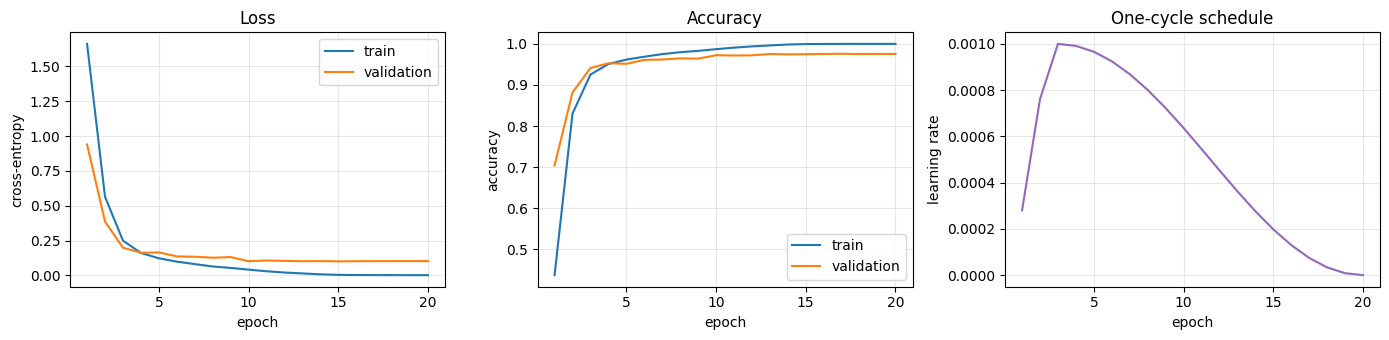

In [15]:
fig, (ax_loss, ax_acc, ax_lr) = plt.subplots(1, 3, figsize=(14, 3.5))

ax_loss.plot(history["epoch"], history["train_loss"], label="train")
ax_loss.plot(history["epoch"], history["val_loss"], label="validation")
ax_loss.set_xlabel("epoch"); ax_loss.set_ylabel("cross-entropy")
ax_loss.set_title("Loss"); ax_loss.legend(); ax_loss.grid(alpha=0.3)

ax_acc.plot(history["epoch"], history["train_acc"], label="train")
ax_acc.plot(history["epoch"], history["val_acc"], label="validation")
ax_acc.set_xlabel("epoch"); ax_acc.set_ylabel("accuracy")
ax_acc.set_title("Accuracy"); ax_acc.legend(); ax_acc.grid(alpha=0.3)

ax_lr.plot(history["epoch"], history["lr"], color="tab:purple")
ax_lr.set_xlabel("epoch"); ax_lr.set_ylabel("learning rate")
ax_lr.set_title("One-cycle schedule"); ax_lr.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Look at the gap between the two accuracy curves. Training accuracy reaches
**100%** — the model memorizes all 33,600 images exactly — while validation
accuracy flattens near 98%, and the validation loss stops improving well before
the training loss does. This is textbook overfitting, and the CNN of the
previous notebook showed nothing like it: its two curves stayed together
throughout.

That difference is not incidental, and it is the same phenomenon Section 13
analyses. With 105,098 parameters and no built-in assumptions about images, the
ViT has both the capacity and the freedom to memorize. The CNN, with weight
sharing forcing it to use one kernel everywhere, cannot memorize as easily even
if it wanted to — its structure constrains it toward explanations that
generalize. Overfitting here is the visible cost of a weak inductive bias.

---
## 10. Evaluation

In [16]:
@torch.no_grad()
def collect_predictions(model, X, batch_size=512):
    model.eval()
    return torch.cat([model(X[i:i + batch_size].to(device)).argmax(dim=1).cpu()
                      for i in range(0, X.size(0), batch_size)])


val_predictions = collect_predictions(model, X_val)
val_accuracy = (val_predictions == Y_val).float().mean().item()
print(f"validation accuracy: {val_accuracy:.4f}")
print(f"errors: {(val_predictions != Y_val).sum().item()} of {Y_val.size(0)}")

validation accuracy: 0.9755
errors: 206 of 8400


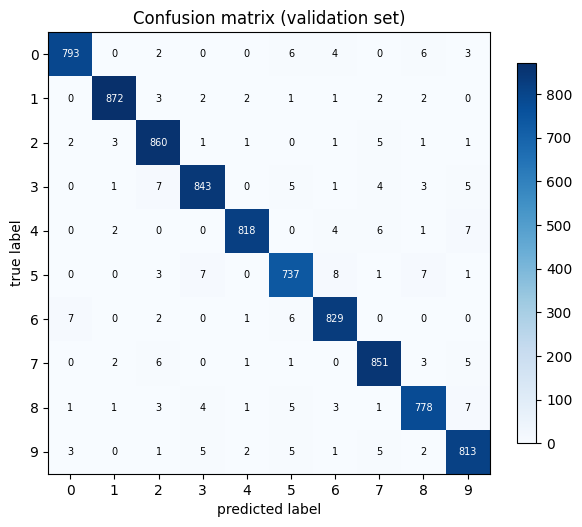

In [17]:
confusion = torch.zeros(10, 10, dtype=torch.long)
for true_label, predicted_label in zip(Y_val, val_predictions):
    confusion[true_label, predicted_label] += 1

fig, ax = plt.subplots(figsize=(6.2, 5.4))
im = ax.imshow(confusion, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("predicted label"); ax.set_ylabel("true label")
ax.set_title("Confusion matrix (validation set)")
for i in range(10):
    for j in range(10):
        ax.text(j, i, confusion[i, j].item(), ha="center", va="center", fontsize=7,
                color="white" if confusion[i, j] > confusion.max() / 2 else "black")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

---
## 11. Reading the attention maps

This is what a transformer offers that a CNN does not: the attention weights are
an explicit, inspectable account of which inputs the model consulted.

We take the `[CLS]` row of the attention matrix $\mathbf{A}$ in the final block —
row 1, since `[CLS]` was prepended, which is `weights[..., 0, :]` in the code.
Entry $j$ of that row is the fraction of its attention the classification token
paid to patch $j$. Dropping the token's attention to
itself and reshaping the remaining 16 weights to the $4 \times 4$ patch grid
gives a map, directly comparable to the image, of where the model looked before
deciding.

Each of the four heads has its own row, and they generally differ: that is the
division of labour Section 6 was arguing for.

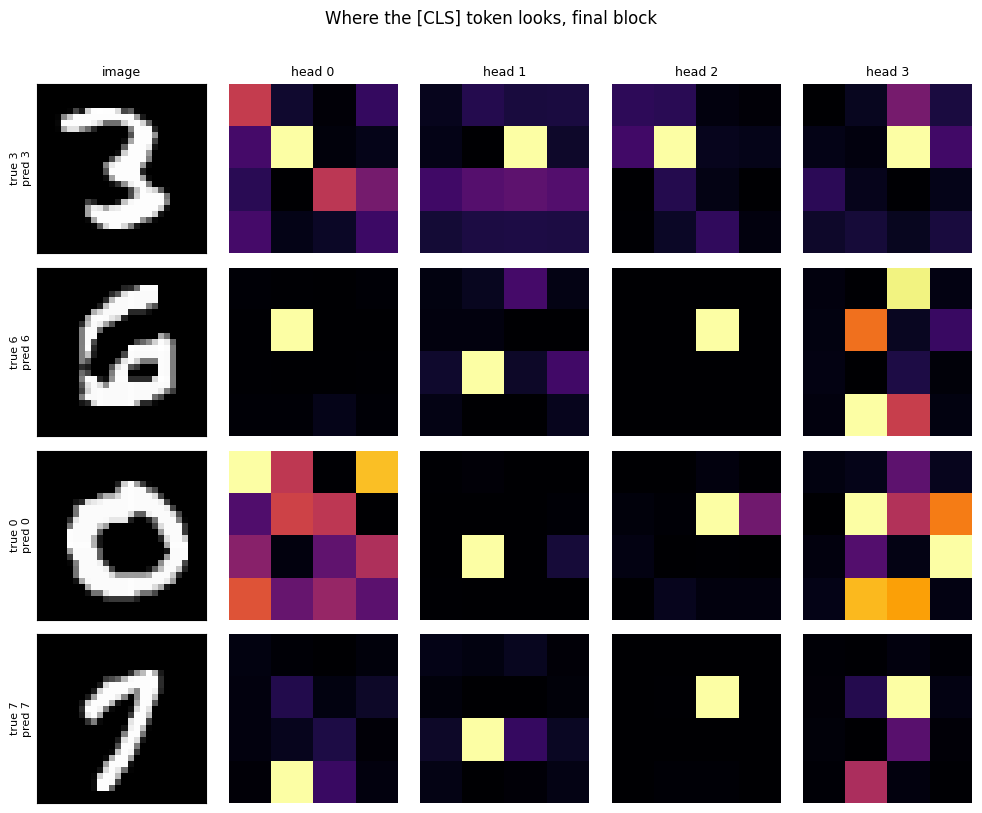

In [18]:
n_show = 4
images = X_val[:n_show].to(device)

model.eval()
with torch.no_grad():
    logits, attention_maps = model(images, return_attention=True)
predictions = logits.argmax(dim=1).cpu()

last_layer = attention_maps[-1]              # (B, heads, 17, 17)
grid = 28 // PATCH

fig, axes = plt.subplots(n_show, N_HEADS + 1, figsize=(2.0 * (N_HEADS + 1), 2.0 * n_show))
for row in range(n_show):
    axes[row, 0].imshow(X_val[row, 0], cmap="gray")
    axes[row, 0].set_ylabel(f"true {Y_val[row].item()}\npred {predictions[row].item()}",
                            fontsize=8)
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    if row == 0:
        axes[row, 0].set_title("image", fontsize=9)

    for head in range(N_HEADS):
        # CLS row, excluding CLS's attention to itself -> 16 patch weights.
        cls_row = last_layer[row, head, 0, 1:].cpu().reshape(grid, grid)
        axes[row, head + 1].imshow(cls_row, cmap="inferno")
        axes[row, head + 1].axis("off")
        if row == 0:
            axes[row, head + 1].set_title(f"head {head}", fontsize=9)

fig.suptitle("Where the [CLS] token looks, final block", y=1.01)
plt.tight_layout()
plt.show()

In [19]:
# How sharply does attention concentrate? Entropy of each CLS row, in bits.
# Uniform over 17 tokens is the maximum, log2(17) = 4.09 bits.
with torch.no_grad():
    _, maps = model(X_val[:512].to(device), return_attention=True)

print(f"maximum possible entropy (uniform over 17 tokens): {np.log2(17):.2f} bits\n")
for layer_index, layer in enumerate(maps):
    cls_rows = layer[:, :, 0, :]                                  # (B, heads, 17)
    entropy = -(cls_rows * torch.log2(cls_rows + 1e-12)).sum(-1)  # (B, heads)
    per_head = entropy.mean(dim=0)
    formatted = "  ".join(f"head {h}: {e:.2f}" for h, e in enumerate(per_head))
    print(f"block {layer_index + 1}   {formatted}")

maximum possible entropy (uniform over 17 tokens): 4.09 bits

block 1   head 0: 3.07  head 1: 2.63  head 2: 2.82  head 3: 2.99
block 2   head 0: 3.27  head 1: 2.86  head 2: 1.99  head 3: 2.54


Entropy makes the behaviour quantitative. A head at the maximum of 4.09 bits is
spreading its attention evenly and effectively averaging the patches; a head
well below it has committed to a few. Heads usually differ here, and comparing
the two blocks shows whether attention sharpens with depth.

Do not over-read these maps. A large attention weight means a patch was read,
not that it was decisive — the value vectors and the MLP determine what is
actually done with the information. Attention maps are evidence about the
model's routing, not a complete explanation of its decision.

---
## 12. The same model, using PyTorch's built-ins

Everything in Sections 5 through 7 already exists in `torch.nn`. Now, we will have the library version: we copy the trained weights out of our
model into the built-in one and check that they produce identical outputs.

### 12.1 What replaces what

| Our class | PyTorch built-in |
|---|---|
| `MultiHeadSelfAttention` (Section 6) | `nn.MultiheadAttention` |
| `TransformerBlock` (Section 7) | `nn.TransformerEncoderLayer` |
| `nn.ModuleList` of blocks (Section 8) | `nn.TransformerEncoder` |

The constructor arguments map onto decisions we made explicitly:

| Argument | Value | Where it came from |
|---|---|---|
| `d_model` | 64 | model width |
| `nhead` | 4 | Section 6, $m = 64/4 = 16$ |
| `dim_feedforward` | 256 | Section 7.3, the $4\times$ expansion |
| `activation` | `"gelu"` | Section 7.3 |
| `norm_first` | `True` | Section 7.4 — **pre-norm**; the default `False` is post-norm |
| `batch_first` | `True` | our tensors are $(B, N, d)$, not $(N, B, d)$ |
| `dropout` | `0.0` | our block has none, and we need an exact match |

Two of those defaults are worth pausing on. `norm_first=False` is the default,
so a careless call gives you the **post-norm** block of the original 2017 paper
rather than the pre-norm one; and `batch_first=False` means PyTorch expects
sequence-first tensors, which is a common source of silently wrong results
rather than errors, because $(B, N, d)$ and $(N, B, d)$ are both valid shapes.

### 12.2 How the parameters correspond

| Ours | Built-in |
|---|---|
| `attn.qkv.weight` $(3d \times d)$ | `self_attn.in_proj_weight` $(3d \times d)$ |
| `attn.qkv.bias` | `self_attn.in_proj_bias` |
| `attn.proj.{weight,bias}` | `self_attn.out_proj.{weight,bias}` |
| `mlp[0].{weight,bias}` | `linear1.{weight,bias}` |
| `mlp[2].{weight,bias}` | `linear2.{weight,bias}` |
| `norm1.{weight,bias}` | `norm1.{weight,bias}` |
| `norm2.{weight,bias}` | `norm2.{weight,bias}` |

The first row is the one to notice. In Section 6 we fused $\mathbf{W}_q,
\mathbf{W}_k, \mathbf{W}_v$ into a single `nn.Linear(d, 3 * d)` and called
`.chunk(3)`. PyTorch does exactly the same thing, in the same
$[\mathbf{Q}; \mathbf{K}; \mathbf{V}]$ row order, under the name
`in_proj_weight` — so the copy is a straight assignment with no reshaping or
reordering. 

In [20]:
class VisionTransformerBuiltin(nn.Module):
    """Identical architecture to VisionTransformer, built from torch.nn layers."""

    def __init__(self, d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 patch=PATCH, n_classes=10, mlp_ratio=MLP_RATIO):
        super().__init__()
        self.patch = patch
        n_patches = (28 // patch) ** 2

        # Unchanged from Section 8 -- PyTorch has no "patchify + CLS" layer.
        self.patch_embed = nn.Linear(patch * patch, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, d_model))

        # This replaces MultiHeadSelfAttention AND TransformerBlock entirely.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=mlp_ratio * d_model,
            dropout=0.0,
            activation="gelu",
            norm_first=True,      # pre-norm, as in Section 7.4
            batch_first=True,     # (B, N, d)
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=n_layers, enable_nested_tensor=False
        )

        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, n_classes)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, images):
        B = images.shape[0]
        z = self.patch_embed(patchify(images, self.patch))
        z = torch.cat([self.cls_token.expand(B, -1, -1), z], dim=1)
        z = z + self.pos_embed
        z = self.encoder(z)                  # the whole stack, one call
        return self.head(self.norm(z)[:, 0])


builtin = VisionTransformerBuiltin().to(device)
print(f"from scratch: {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"built-in:     {sum(p.numel() for p in builtin.parameters()):,} parameters")

from scratch: 105,098 parameters
built-in:     105,098 parameters


Identical parameter counts are a good sign but not a proof — two different
architectures can coincidentally agree. The real test is whether the built-in
model, given our trained weights, reproduces our outputs.

In [21]:
@torch.no_grad()
def copy_weights(source, target):
    """Copy every parameter of our ViT into the equivalent built-in module."""
    target.patch_embed.load_state_dict(source.patch_embed.state_dict())
    target.cls_token.copy_(source.cls_token)
    target.pos_embed.copy_(source.pos_embed)
    target.norm.load_state_dict(source.norm.state_dict())
    target.head.load_state_dict(source.head.state_dict())

    for ours, theirs in zip(source.blocks, target.encoder.layers):
        # Fused QKV: our nn.Linear(d, 3d) is PyTorch's in_proj_weight verbatim.
        theirs.self_attn.in_proj_weight.copy_(ours.attn.qkv.weight)
        theirs.self_attn.in_proj_bias.copy_(ours.attn.qkv.bias)
        theirs.self_attn.out_proj.load_state_dict(ours.attn.proj.state_dict())

        theirs.linear1.load_state_dict(ours.mlp[0].state_dict())
        theirs.linear2.load_state_dict(ours.mlp[2].state_dict())

        theirs.norm1.load_state_dict(ours.norm1.state_dict())
        theirs.norm2.load_state_dict(ours.norm2.state_dict())


copy_weights(model, builtin)

model.eval()
builtin.eval()
probe = X_val[:256].to(device)
with torch.no_grad():
    logits_scratch = model(probe)
    logits_builtin = builtin(probe)

difference = (logits_scratch - logits_builtin).abs().max().item()
print(f"largest absolute difference in logits: {difference:.3e}")
print(f"identical predictions: "
      f"{(logits_scratch.argmax(1) == logits_builtin.argmax(1)).all().item()}")
print(f"allclose (atol=1e-5): "
      f"{torch.allclose(logits_scratch, logits_builtin, atol=1e-5)}")

largest absolute difference in logits: 0.000e+00
identical predictions: True
allclose (atol=1e-5): True


The two implementations agree to floating-point round-off. Whatever residual
difference remains comes from PyTorch's fused attention kernel summing in a
different order, not from a difference in the mathematics.

That result is an
independent check that the code you wrote in Sections 5–7 is correct. If the
hand-written version had a transposed matrix or a softmax over the wrong axis,
the logits would not match.

In [22]:
# The same weights, evaluated over the whole validation set both ways.
scratch_predictions = collect_predictions(model, X_val)
builtin_predictions = collect_predictions(builtin, X_val)

scratch_accuracy = (scratch_predictions == Y_val).float().mean().item()
builtin_accuracy = (builtin_predictions == Y_val).float().mean().item()

print(f"from scratch: {scratch_accuracy:.4f}")
print(f"built-in:     {builtin_accuracy:.4f}")
print(f"predictions agree on {(scratch_predictions == builtin_predictions).float().mean():.4%} "
      f"of the {Y_val.size(0)} validation images")

from scratch: 0.9755
built-in:     0.9755
predictions agree on 100.0000% of the 8400 validation images


### 12.3 What you gain, and what you give up

**Gain.** Fewer lines, fewer mistakes, and a fused attention kernel — PyTorch
dispatches to FlashAttention-style implementations that never materialize the
full $N \times N$ score matrix, which at long sequence lengths is the difference
between fitting in memory and not. At our $N = 17$ it hardly matters; at
$N = 4096$ it is decisive.

**Give up.** Access to the internals. Section 11's per-head attention maps are
awkward to obtain from `nn.TransformerEncoderLayer`: it does not return
attention weights, so you need a forward hook on `self_attn`, and
`nn.MultiheadAttention` **averages over heads by default** — you must pass
`average_attn_weights=False` to recover per-head maps at all. The fused kernels
may not expose the weights whatsoever, since not building the score matrix is
precisely how they save memory.


### 12.4 The middle ground

Between the two extremes sits `F.scaled_dot_product_attention`, which computes
Section 5.2's formula in one optimized, fused call while leaving the surrounding
architecture to you:

```python
# Replaces the three middle lines of our forward pass:
#     scores  = q @ k.transpose(-2, -1) / self.d_k ** 0.5
#     weights = scores.softmax(dim=-1)
#     context = weights @ v
context = F.scaled_dot_product_attention(q, k, v)   # same shapes, fused
```

It takes and returns $(B, h, N, m)$ — exactly the layout our `split_heads`
already produces — and handles the $1/\sqrt{m}$ scaling internally. It also
accepts `is_causal=True`, which applies the triangular mask that turns this
encoder into the decoder of a language model.

**In real work, use the built-ins.** The point of Sections 5–7 was never that
you should write attention by hand, but that you should know what these three
lines are doing when you call them.

In [23]:
# The middle ground, verified against our hand-written attention.
sample = z0.to(device)
layer = model.blocks[0].attn

with torch.no_grad():
    B, N, D = sample.shape
    q, k, v = layer.qkv(sample).chunk(3, dim=-1)
    q, k, v = (t.view(B, N, layer.n_heads, layer.d_k).transpose(1, 2) for t in (q, k, v))

    manual = (q @ k.transpose(-2, -1) / layer.d_k ** 0.5).softmax(-1) @ v
    fused = F.scaled_dot_product_attention(q, k, v)

print(f"our three lines vs F.scaled_dot_product_attention: "
      f"max difference {(manual - fused).abs().max().item():.3e}")
print(f"allclose: {torch.allclose(manual, fused, atol=1e-6)}")

our three lines vs F.scaled_dot_product_attention: max difference 0.000e+00
allclose: True


---
## 13. Why the CNN still wins, and what to do about it

### The three notebooks

| | Dense (NumPy) | CNN (PyTorch) | ViT (this notebook) |
|---|---|---|---|
| Parameters | 7,960 | 9,098 | 105,098 |
| Validation accuracy | 90.8% | 98.1% | ~97.5–98% |
| Error rate | 9.2% | 1.9% | ~2.0–2.5% |
| Structural assumption | none | locality + translation equivariance | permutation equivariance only |
| Receptive field, layer 1 | global | $3\times3$ | global |
| Epochs | — (1,000 full-batch steps) | 10 | 20 |

The Vision Transformer uses **11.6×** the CNN's parameters to arrive at the same
place. Be careful about how strongly you read the accuracy column: 2.1% against
1.9% error is a difference of about 17 images out of 8,400, which is roughly one
standard error — and rerunning this notebook moves the ViT by a comparable
amount on its own. The defensible claim is **parity at 11.6× the parameter
cost**, not that one architecture outranks the other.

What is not within noise is the cost, and the overfitting: the ViT drives
training accuracy to 100% while validation stalls, which the CNN never did.
Those are the observations the argument below rests on.

### Inductive bias

A convolution has strong assumptions built into its structure: that nearby
pixels are related, and that a feature is the same feature wherever it appears.
Those assumptions are *correct* for images, and because they are baked into the
architecture, the CNN does not need to spend data learning them.

A transformer assumes almost nothing. Self-attention treats its input as a set,
and the only spatial information it gets is whatever the positional embeddings
manage to encode. Everything a convolution knows a priori — adjacency,
locality, translation equivariance — the ViT must infer from examples. With
33,600 training images there is not enough evidence to infer it well.

This is precisely what the ViT paper reported: transformers underperform
comparable CNNs on ImageNet-scale data alone, and overtake them only after
pretraining on much larger corpora (14M–300M images). Our result reproduces the
small-data half of that finding, at a scale that trains in a minute.

The general lesson outlives both architectures: **when data is scarce, a correct
inductive bias beats flexibility; when data is abundant, flexibility wins.**

### So why use transformers at all?

Because the same architecture, unmodified, handles text, audio, images, and
protein sequences — anything expressible as a sequence of tokens. Because
attention scales with data and compute in a way convolutions do not. And because
the attention maps of Section 11 are inspectable in a way convolutional features
are not. On 33,600 MNIST digits none of those advantages can pay off. At scale
they dominate, which is why essentially every frontier model is a transformer.

### The PyTorch equivalent

Section 12 builds this same model from `nn.TransformerEncoder` and proves
the two implementations agree to floating-point round-off by copying the
trained weights across.
